In [1]:
MODEL_CLS = "cfnet"
DATASET = "movielens"
STRATEGY = "pairwise"
PATH_WORK_DIR = "../.."

In [ ]:
if DATASET=="abeauty":
    NUM_USERS = 3819
    NUM_ITEMS = 1581
elif DATASET=="amusic":
    NUM_USERS = 5541
    NUM_ITEMS = 3568
elif DATASET=="lastfm":
    NUM_USERS = 1892
    NUM_ITEMS = 17632
elif DATASET=="movielens":
    NUM_USERS = 610
    NUM_ITEMS = 9724
else:
    raise ValueError()

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PAPER REVIEW\RECSYS\03_OCCF\01_RS-BPR


In [5]:
import sys
sys.path.append("src")

# Config

In [6]:
import pandas as pd
from components import interactions
from pairwise import config, datamodule, trainer, evaluator, utils
import lfm

In [ ]:
PATH = f"./config/{MODEL_CLS}_{STRATEGY}.yaml"
cfg = config.build(PATH)

In [8]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [9]:
PATH = f"./data/{DATASET}.csv"
df = pd.read_csv(PATH)

In [10]:
kwargs = dict(
    df=df,
    percentile=0.9,
)

utils.desc.main(**kwargs)

number of user: 610
number of item: 9724
total interaction: 100836
interaction density: 1.7000 %
max interaction of user: 2698
max interaction of item: 329
top 10.0 % interaction of user: 400.3
top 10.0 % interaction of item: 27.0
mean interaction of user: 165
mean interaction of item: 10


In [11]:
kwargs = dict(
    df=df,
    cfg=cfg.datamodule,
)

dataloaders, trn = datamodule.build(**kwargs)

In [12]:
kwargs = dict(
    df=trn,
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
)

interactions_cls = interactions.Interactions(**kwargs)

# Modeling

In [13]:
kwargs = dict(
    interactions=interactions_cls,
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    **cfg.model["rlnet"].params,
)

rlnet_cls = lfm.rlnet.RepresentationLearningNetworks(**kwargs)

In [14]:
kwargs = dict(
    interactions=interactions_cls,
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    **cfg.model["mlnet"].params,
)

mlnet_cls = lfm.mlnet.MatchingLearningNetworks(**kwargs)

In [15]:
kwargs = dict(
    rlnet=rlnet_cls,
    mlnet=mlnet_cls,
)

model = lfm.cfnet.CollaborativeFilteringNetworks(**kwargs)

# Train

In [16]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

opt = trainer.build(**kwargs)

In [17]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = opt.fit(**kwargs)

BEST EPOCH: 19
BEST SCORE: 0.5274


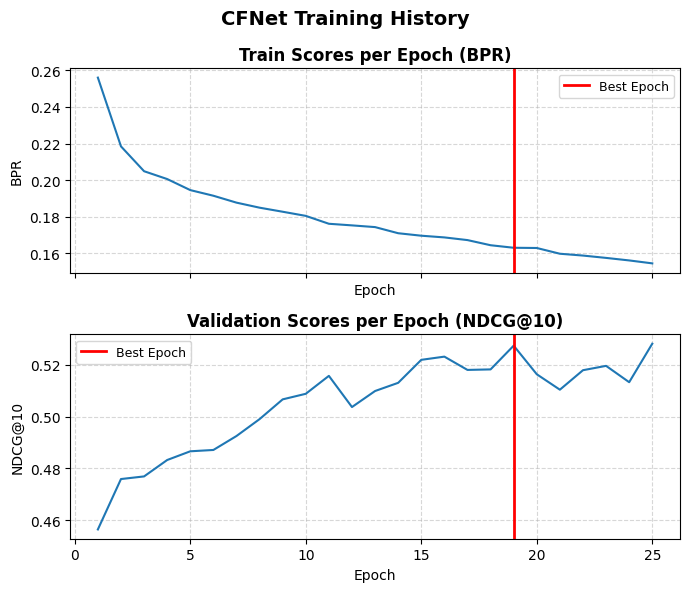

In [18]:
kwargs = dict(
    records=records,
    suptitle="CFNet Training History",
    trn="BPR",
    val="NDCG@10",
    figsize=(7,3),
)

utils.visualizer.main(**kwargs)

# Test

In [19]:
kwargs = dict(
    model=model,
    cutoff=[5,10,15,20,25,50],
)

msr = evaluator.build(**kwargs)

In [20]:
result, metrics_sheet = msr(dataloaders["tst"])

TST: 100%|██████████| 986/986 [00:05<00:00, 189.87it/s]


In [21]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.870492,0.423279,0.307334,0.233802,0.497592
1,10,0.940984,0.327049,0.436291,0.289062,0.503307
2,15,0.972131,0.271038,0.506572,0.310948,0.513191
3,20,0.985246,0.236311,0.561940,0.325325,0.524916
4,25,0.991803,0.212393,0.606510,0.335884,0.536146
5,50,1.000000,0.142164,0.719698,0.358352,0.566207


# Save

In [22]:
PATH = f'./checkpoints/{DATASET}/{MODEL_CLS}_{STRATEGY}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)